In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv("C:\\Users\\knaaz\\OneDrive\\Documents\\Customer-Segmentation-CLV-Analysis\\data\\raw\\customer_analysis.csv")

In [5]:
df.head()

,customer_id,recency,frequency,monetary,avg_order_value,customer_lifespan_days,first_purchase_date,last_purchase_date,country
0,12346,326,1,77183.60,77183.600000,0,2011-01-18 10:01:00,2011-01-18 10:01:00,United Kingdom
1,12347,3,7,4310.00,615.714286,365,2010-12-07 14:57:00,2011-12-07 15:52:00,Iceland
2,12348,76,4,1797.24,449.310000,283,2010-12-16 19:09:00,2011-09-25 13:13:00,Finland
3,12349,19,1,1757.55,1757.550000,0,2011-11-21 09:51:00,2011-11-21 09:51:00,Italy
4,12350,311,1,334.40,334.400000,0,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway


In [6]:
df.shape

(4338, 9)

In [7]:
df.columns

Index(['customer_id', 'recency', 'frequency', 'monetary', 'avg_order_value',
       'customer_lifespan_days', 'first_purchase_date', 'last_purchase_date',
       'country'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             4338 non-null   int64  
 1   recency                 4338 non-null   int64  
 2   frequency               4338 non-null   int64  
 3   monetary                4338 non-null   float64
 4   avg_order_value         4338 non-null   float64
 5   customer_lifespan_days  4338 non-null   int64  
 6   first_purchase_date     4338 non-null   str    
 7   last_purchase_date      4338 non-null   str    
 8   country                 4338 non-null   str    
dtypes: float64(2), int64(4), str(3)
memory usage: 305.1 KB


In [9]:
df.isnull().sum()

customer_id               0
recency                   0
frequency                 0
monetary                  0
avg_order_value           0
customer_lifespan_days    0
first_purchase_date       0
last_purchase_date        0
country                   0
dtype: int64

In [10]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
df.dtypes

customer_id                 int64
recency                     int64
frequency                   int64
monetary                  float64
avg_order_value           float64
customer_lifespan_days      int64
first_purchase_date           str
last_purchase_date            str
country                       str
dtype: object

In [12]:
print(df.columns)

Index(['customer_id', 'recency', 'frequency', 'monetary', 'avg_order_value',
       'customer_lifespan_days', 'first_purchase_date', 'last_purchase_date',
       'country'],
      dtype='str')


In [16]:
df['first_purchase_date'] = pd.to_datetime(df['first_purchase_date'])
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'])

In [17]:
df.describe()

,customer_id,recency,frequency,monetary,avg_order_value,customer_lifespan_days,first_purchase_date,last_purchase_date
count,4338.000000,4338.000000,4338.000000,4338.00000,4338.000000,4338.000000,4338,4338
mean,15300.408022,93.059474,4.272015,2048.68808,417.645734,130.771554,2011-04-30 17:06:50.857538,2011-09-08 11:38:59.045643
min,12346.000000,1.000000,1.000000,3.75000,3.450000,0.000000,2010-12-01 08:26:00,2010-12-01 09:53:00
25%,13813.250000,18.000000,1.000000,306.48250,177.867083,0.000000,2011-01-17 11:13:15,2011-07-20 19:18:00
50%,15299.500000,51.000000,2.000000,668.57000,291.940000,93.000000,2011-04-05 09:52:30,2011-10-20 10:40:30
75%,16778.750000,142.750000,5.000000,1660.59750,428.280625,252.000000,2011-08-19 10:11:30,2011-11-22 11:05:45
max,18287.000000,374.000000,209.000000,280206.02000,84236.250000,373.000000,2011-12-09 12:16:00,2011-12-09 12:50:00
std,1721.808492,100.012264,7.697998,8985.23022,1796.511343,132.210509,NaN,NaN


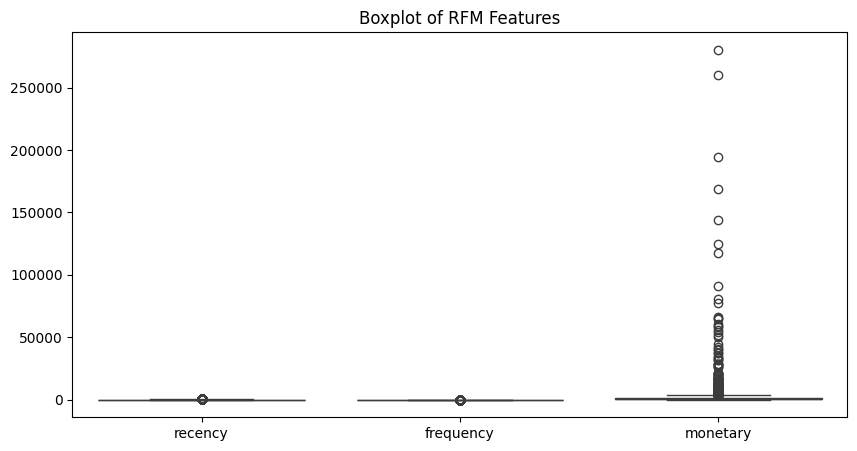

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['recency','frequency','monetary']])
plt.title("Boxplot of RFM Features")
plt.show()

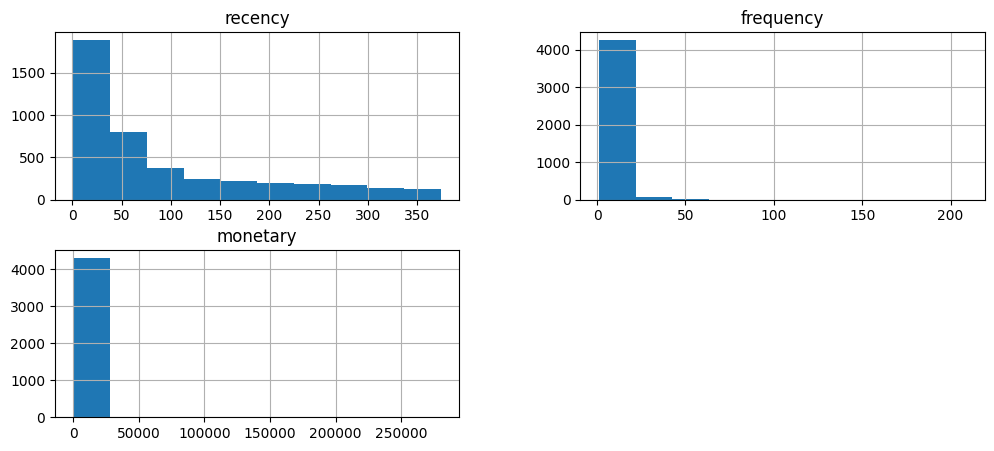

In [19]:
df[['recency','frequency','monetary']].hist(figsize=(12,5))
plt.show()

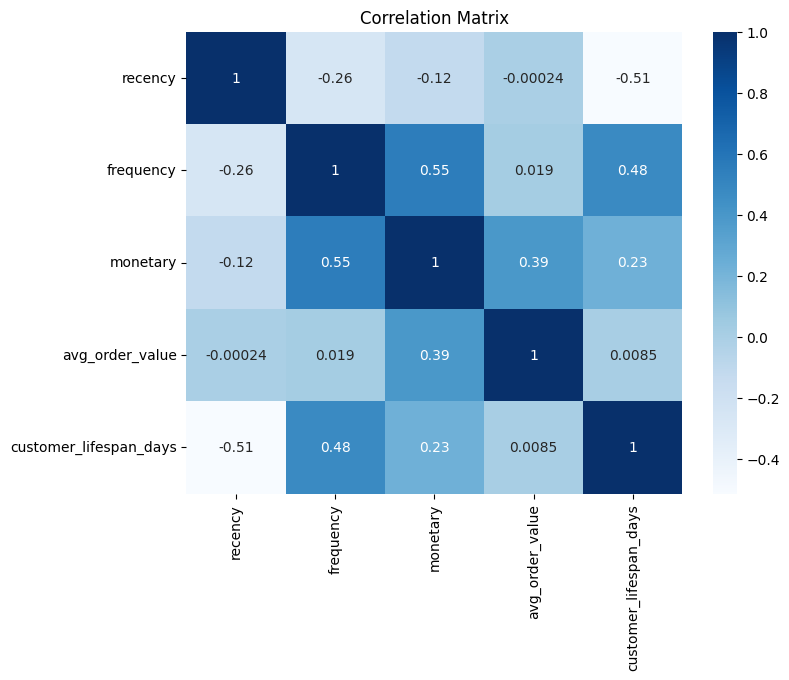

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['recency','frequency','monetary','avg_order_value','customer_lifespan_days']].corr(),
            annot=True,
            cmap='Blues')
plt.title("Correlation Matrix")
plt.show()

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    df[['recency','frequency','monetary']]
)

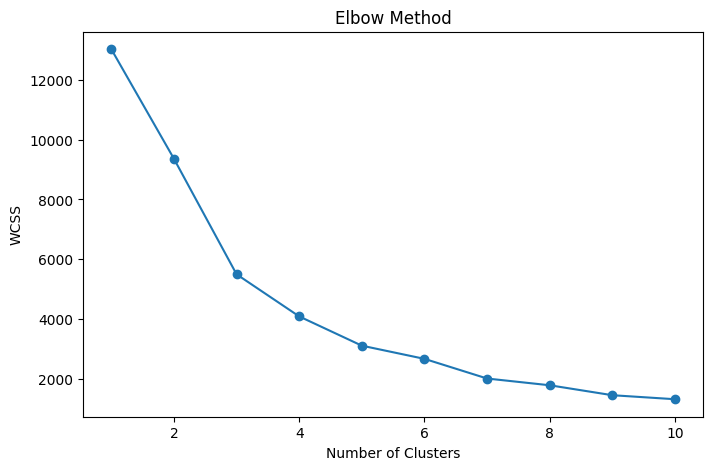

In [22]:
from sklearn.cluster import KMeans

sse = []

for i in range(1,11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(rfm_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), sse, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [23]:
# Apply K-Means with 4 clusters

kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Display first few rows
df.head()

,customer_id,recency,frequency,monetary,avg_order_value,customer_lifespan_days,first_purchase_date,last_purchase_date,country,Cluster
0,12346,326,1,77183.60,77183.600000,0,2011-01-18 10:01:00,2011-01-18 10:01:00,United Kingdom,3
1,12347,3,7,4310.00,615.714286,365,2010-12-07 14:57:00,2011-12-07 15:52:00,Iceland,0
2,12348,76,4,1797.24,449.310000,283,2010-12-16 19:09:00,2011-09-25 13:13:00,Finland,0
3,12349,19,1,1757.55,1757.550000,0,2011-11-21 09:51:00,2011-11-21 09:51:00,Italy,0
4,12350,311,1,334.40,334.400000,0,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway,1


In [24]:
# Count customers in each cluster

df['Cluster'].value_counts().sort_index()

Cluster
0    3060
1    1061
2      13
3     204
Name: count, dtype: int64

In [25]:
cluster_summary = df.groupby('Cluster')[['recency',
                                         'frequency',
                                         'monetary',
                                         'avg_order_value',
                                         'customer_lifespan_days']].mean()

cluster_summary

,recency,frequency,monetary,avg_order_value,customer_lifespan_days
Cluster,,,,,
0,44.433007,3.678758,1352.753575,375.278442,152.028758
1,249.173421,1.551367,476.416023,312.717355,27.847314
2,7.615385,82.538462,127187.959231,8569.264217,347.846154
3,15.955882,22.333333,12690.500392,1079.419682,333.387255


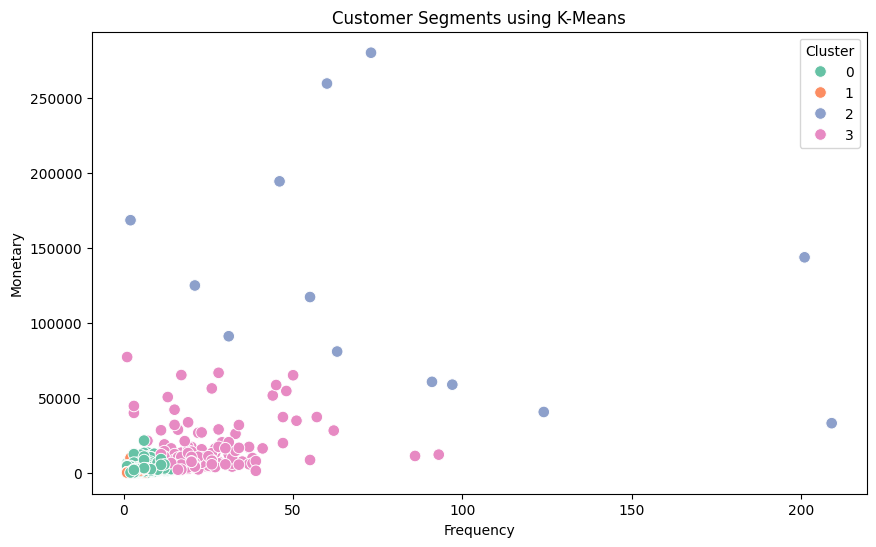

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='frequency',
    y='monetary',
    hue='Cluster',
    palette='Set2',
    s=70
)

plt.title("Customer Segments using K-Means")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()

In [27]:
# Calculate CLV

df['CLV'] = (
    df['avg_order_value']
    * df['frequency']
    * (df['customer_lifespan_days'] / 365)
)

df.head()

,customer_id,recency,frequency,monetary,avg_order_value,customer_lifespan_days,first_purchase_date,last_purchase_date,country,Cluster,CLV
0,12346,326,1,77183.60,77183.600000,0,2011-01-18 10:01:00,2011-01-18 10:01:00,United Kingdom,3,0.000000
1,12347,3,7,4310.00,615.714286,365,2010-12-07 14:57:00,2011-12-07 15:52:00,Iceland,0,4310.000000
2,12348,76,4,1797.24,449.310000,283,2010-12-16 19:09:00,2011-09-25 13:13:00,Finland,0,1393.476493
3,12349,19,1,1757.55,1757.550000,0,2011-11-21 09:51:00,2011-11-21 09:51:00,Italy,0,0.000000
4,12350,311,1,334.40,334.400000,0,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway,1,0.000000


In [28]:
clv_summary = df.groupby('Cluster')['CLV'].mean()

clv_summary

Cluster
0       812.277344
1        66.057341
2    119277.567165
3     11068.525683
Name: CLV, dtype: float64

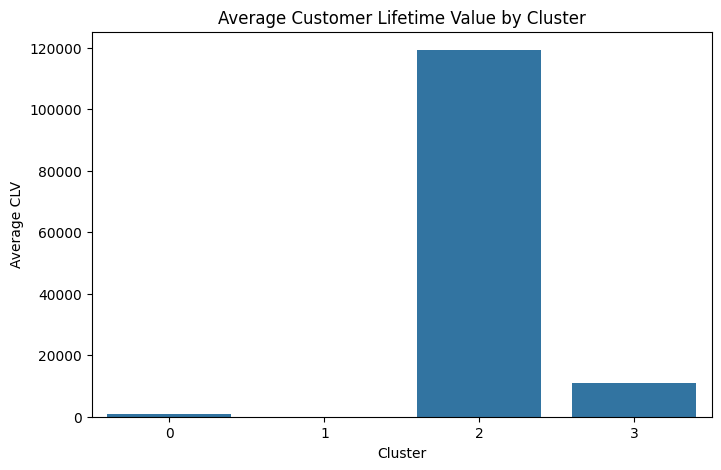

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=clv_summary.index,
    y=clv_summary.values
)

plt.title("Average Customer Lifetime Value by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average CLV")

plt.show()

In [30]:
segment_names = {
    0: "Potential Customers",
    1: "At Risk Customers",
    2: "Champions",
    3: "Loyal Customers"
}

df["Segment"] = df["Cluster"].map(segment_names)

df.head()

,customer_id,recency,frequency,monetary,avg_order_value,customer_lifespan_days,first_purchase_date,last_purchase_date,country,Cluster,CLV,Segment
0,12346,326,1,77183.60,77183.600000,0,2011-01-18 10:01:00,2011-01-18 10:01:00,United Kingdom,3,0.000000,Loyal Customers
1,12347,3,7,4310.00,615.714286,365,2010-12-07 14:57:00,2011-12-07 15:52:00,Iceland,0,4310.000000,Potential Customers
2,12348,76,4,1797.24,449.310000,283,2010-12-16 19:09:00,2011-09-25 13:13:00,Finland,0,1393.476493,Potential Customers
3,12349,19,1,1757.55,1757.550000,0,2011-11-21 09:51:00,2011-11-21 09:51:00,Italy,0,0.000000,Potential Customers
4,12350,311,1,334.40,334.400000,0,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway,1,0.000000,At Risk Customers


In [31]:
df["Segment"].value_counts()

Segment
Potential Customers    3060
At Risk Customers      1061
Loyal Customers         204
Champions                13
Name: count, dtype: int64

In [32]:
df.groupby("Segment")["CLV"].mean().sort_values(ascending=False)

Segment
Champions              119277.567165
Loyal Customers         11068.525683
Potential Customers       812.277344
At Risk Customers          66.057341
Name: CLV, dtype: float64

In [33]:

# this file  will be used in the power bi

df.to_csv("../data/processed/customer_segmented_clv.csv", index=False)

print("Dataset Exported Successfully!")

Dataset Exported Successfully!
